In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, cross_validate
from xgboost import XGBRegressor

# Tải dữ liệu dạng bảng California Housing
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
print("Đã tải dữ liệu thành công!")
X.head()

Đã tải dữ liệu thành công!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
# 1. Thiet lap Tab Protocol: Kiem chung cheo 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Khoi tao mo hinh XGBoost
model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)

# 3. Tien hanh kiem chung (Luu y: Chuyen return_train_score thanh True de xem Overfitting)
metrics = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']
cv_results = cross_validate(model, X, y, cv=kf, scoring=metrics, return_train_score=True)

# 4. Xuat bang ket qua so sanh Train vs Test phuc vu viet Chuong 4
print("========= BANG DANH GIA OVERFITTING TRÊN TẬP TRAIN VS TEST =========")
print(f"R2 Score    | Tập TRAIN: {np.mean(cv_results['train_r2']):.4f} | Tập TEST (Validation): {np.mean(cv_results['test_r2']):.4f}")
print(f"RMSE Score  | Tập TRAIN: {np.mean(np.sqrt(-cv_results['train_neg_mean_squared_error'])):.4f} | Tập TEST (Validation): {np.mean(np.sqrt(-cv_results['test_neg_mean_squared_error'])):.4f}")
print(f"MAE Score   | Tập TRAIN: {np.mean(-cv_results['train_neg_mean_absolute_error']):.4f} | Tập TEST (Validation): {np.mean(-cv_results['test_neg_mean_absolute_error']):.4f}")

========= BANG DANH GIA OVERFITTING TRÊN TẬP TRAIN VS TEST =========
R2 Score    | Tập TRAIN: 0.8973 | Tập TEST (Validation): 0.8324
RMSE Score  | Tập TRAIN: 0.3697 | Tập TEST (Validation): 0.4721
MAE Score   | Tập TRAIN: 0.2563 | Tập TEST (Validation): 0.3142


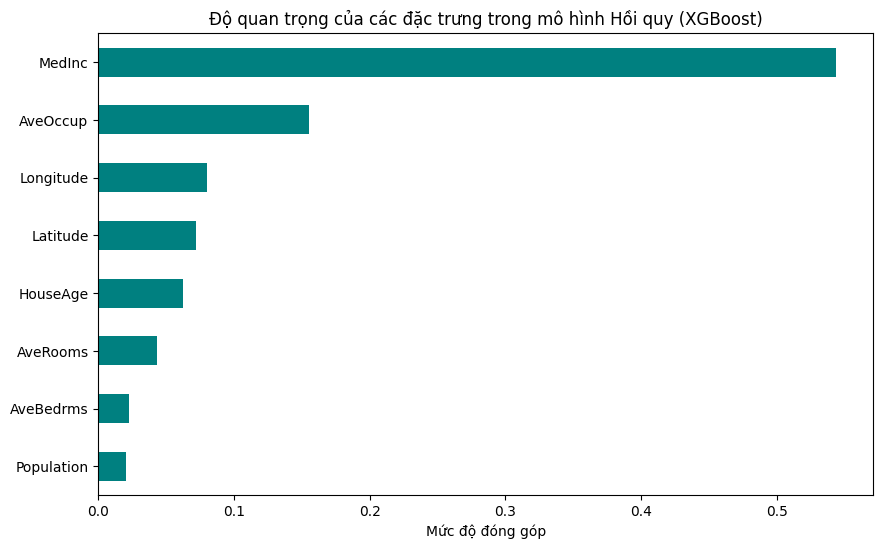

In [9]:
# Huấn luyện trên toàn bộ dữ liệu để lấy Feature Importance
model.fit(X, y)

# Sắp xếp và vẽ biểu đồ
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Độ quan trọng của các đặc trưng trong mô hình Hồi quy (XGBoost)')
plt.xlabel('Mức độ đóng góp')
plt.show()